Grid spacing dx = 0.01
Grid spacing dy = 0.01
Stable dt limit = 0.25
Using dt = 0.125


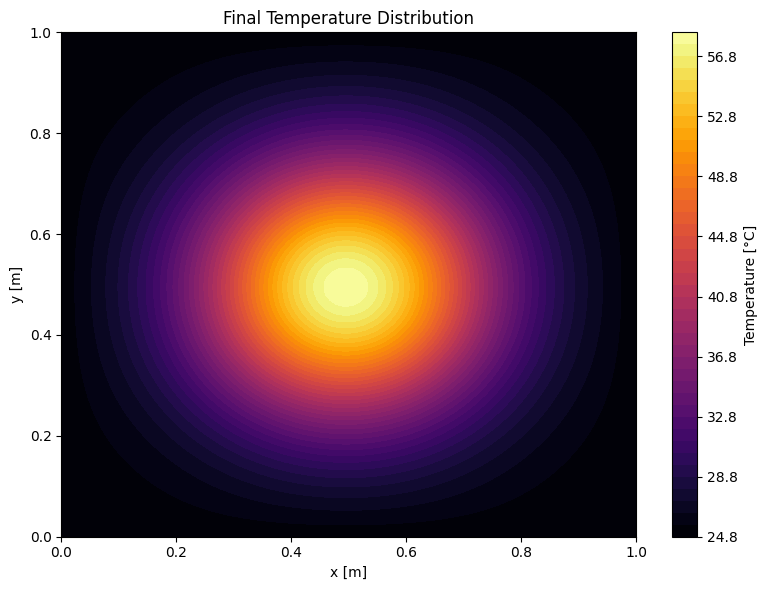

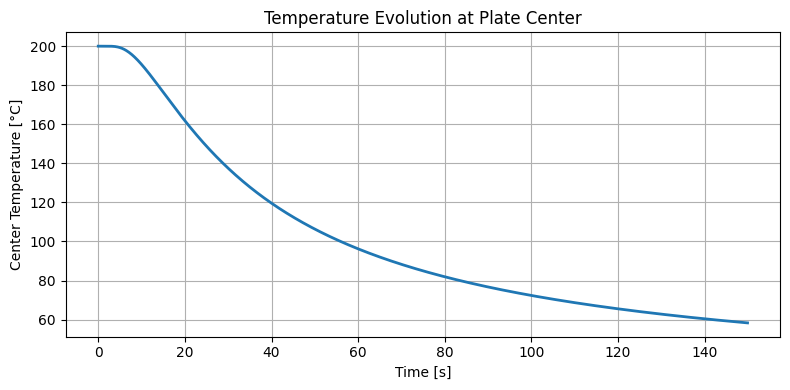

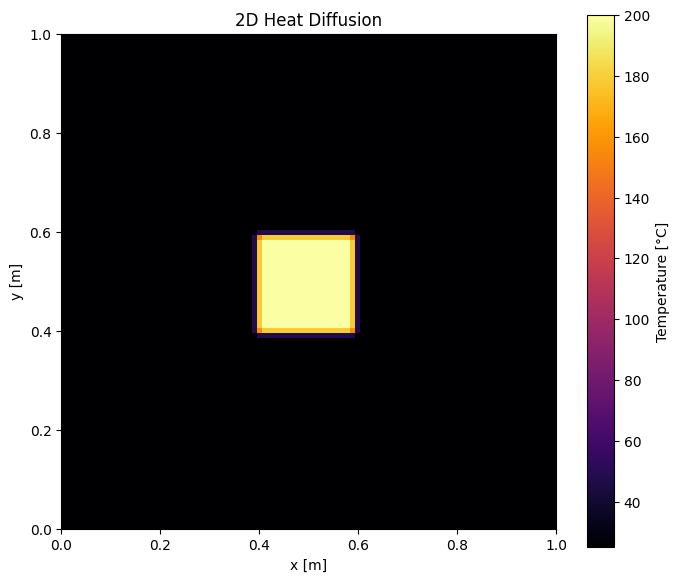

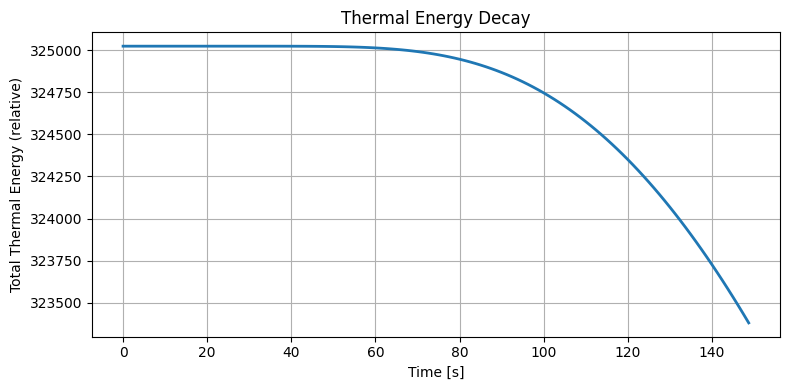

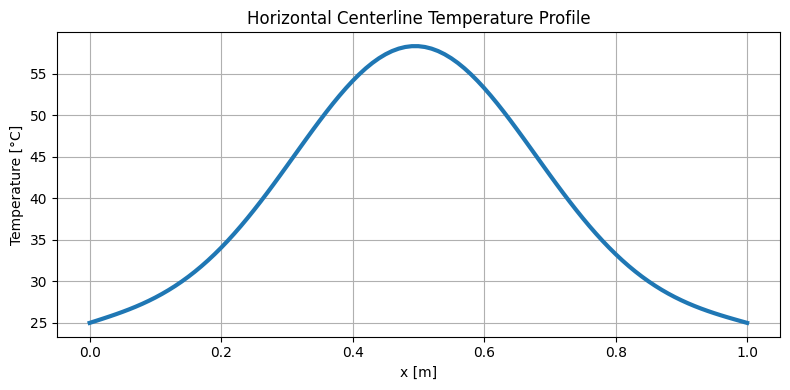


Simulation completed successfully.
------------------------------------------------
Domain size        : 1.0 x 1.0 m
Grid resolution    : 101 x 101
Time step          : 1.250000e-01 s
Number of steps    : 1200
Thermal diffusivity: 1.00e-04 m^2/s
------------------------------------------------


In [1]:
# ================================================================
# 2D Heat Diffusion in a Plate
# ================================================================
# Single-file executable notebook script
# Copy and paste into a Jupyter Notebook cell
#
# This simulation solves the transient 2D heat diffusion equation:
#
#     dT/dt = alpha * (d²T/dx² + d²T/dy²)
#
# using an explicit finite difference method.
#
# Features:
# - 2D transient heat conduction
# - Animated temperature field
# - Temperature contour visualization
# - Centerline temperature evolution
# - Stable explicit numerical scheme
#
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ================================================================
# PHYSICAL PARAMETERS
# ================================================================

Lx = 1.0               # Plate length in x-direction [m]
Ly = 1.0               # Plate length in y-direction [m]

nx = 101               # Number of grid points in x
ny = 101               # Number of grid points in y

alpha = 1.0e-4         # Thermal diffusivity [m^2/s]

# ================================================================
# NUMERICAL PARAMETERS
# ================================================================

dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

# Stability condition for explicit scheme
dt_stable = dx**2 * dy**2 / (2 * alpha * (dx**2 + dy**2))

safety_factor = 0.5
dt = safety_factor * dt_stable

nt = 1200              # Number of time steps

print("Grid spacing dx =", dx)
print("Grid spacing dy =", dy)
print("Stable dt limit =", dt_stable)
print("Using dt =", dt)

# ================================================================
# CREATE GRID
# ================================================================

x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)

X, Y = np.meshgrid(x, y)

# ================================================================
# INITIAL TEMPERATURE FIELD
# ================================================================

T = np.ones((ny, nx)) * 25.0

# Hot square region in the center
cx1 = int(nx * 0.4)
cx2 = int(nx * 0.6)

cy1 = int(ny * 0.4)
cy2 = int(ny * 0.6)

T[cy1:cy2, cx1:cx2] = 200.0

# Storage array
T_new = T.copy()

# ================================================================
# BOUNDARY CONDITIONS
# ================================================================
# Dirichlet boundaries:
# Plate edges fixed at 25 °C

T_top = 25.0
T_bottom = 25.0
T_left = 25.0
T_right = 25.0

# ================================================================
# STORAGE FOR VISUALIZATION
# ================================================================

frames = []
center_temperature = []

save_every = 10

# ================================================================
# TIME INTEGRATION LOOP
# ================================================================

for n in range(nt):

    # Interior nodes update
    T_new[1:-1, 1:-1] = (
        T[1:-1, 1:-1]
        + alpha * dt *
        (
            (T[1:-1, 2:] - 2*T[1:-1, 1:-1] + T[1:-1, :-2]) / dx**2
            +
            (T[2:, 1:-1] - 2*T[1:-1, 1:-1] + T[:-2, 1:-1]) / dy**2
        )
    )

    # Apply boundary conditions
    T_new[0, :] = T_bottom
    T_new[-1, :] = T_top
    T_new[:, 0] = T_left
    T_new[:, -1] = T_right

    # Update solution
    T[:, :] = T_new[:, :]

    # Save center temperature
    center_temperature.append(T[ny//2, nx//2])

    # Save animation frame
    if n % save_every == 0:
        frames.append(T.copy())

# ================================================================
# FINAL TEMPERATURE FIELD
# ================================================================

plt.figure(figsize=(8, 6))

contour = plt.contourf(
    X,
    Y,
    T,
    levels=50,
    cmap='inferno'
)

plt.colorbar(contour, label='Temperature [°C]')

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.title('Final Temperature Distribution')

plt.tight_layout()
plt.show()

# ================================================================
# CENTER TEMPERATURE EVOLUTION
# ================================================================

time_array = np.arange(nt) * dt

plt.figure(figsize=(8, 4))

plt.plot(time_array, center_temperature, linewidth=2)

plt.xlabel('Time [s]')
plt.ylabel('Center Temperature [°C]')

plt.title('Temperature Evolution at Plate Center')

plt.grid(True)

plt.tight_layout()
plt.show()

# ================================================================
# ANIMATION
# ================================================================

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    frames[0],
    origin='lower',
    extent=[0, Lx, 0, Ly],
    cmap='inferno',
    vmin=25,
    vmax=200,
    animated=True
)

cbar = plt.colorbar(image)
cbar.set_label('Temperature [°C]')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

title = ax.set_title('2D Heat Diffusion')

def update(frame):

    image.set_array(frames[frame])

    current_time = frame * save_every * dt

    title.set_text(
        f'2D Heat Diffusion\n'
        f'Time = {current_time:.2f} s'
    )

    return image, title

animation = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=50,
    blit=False
)

plt.tight_layout()
plt.show()

# ================================================================
# ENERGY DECAY ANALYSIS
# ================================================================

energy = []

for frame in frames:
    energy.append(np.sum(frame))

plt.figure(figsize=(8, 4))

plt.plot(
    np.arange(len(frames)) * save_every * dt,
    energy,
    linewidth=2
)

plt.xlabel('Time [s]')
plt.ylabel('Total Thermal Energy (relative)')

plt.title('Thermal Energy Decay')

plt.grid(True)

plt.tight_layout()
plt.show()

# ================================================================
# CROSS SECTION TEMPERATURE
# ================================================================

mid_y = ny // 2

plt.figure(figsize=(8, 4))

plt.plot(
    x,
    T[mid_y, :],
    linewidth=3
)

plt.xlabel('x [m]')
plt.ylabel('Temperature [°C]')

plt.title('Horizontal Centerline Temperature Profile')

plt.grid(True)

plt.tight_layout()
plt.show()

# ================================================================
# SIMULATION SUMMARY
# ================================================================

print("\nSimulation completed successfully.")
print("------------------------------------------------")
print(f"Domain size        : {Lx} x {Ly} m")
print(f"Grid resolution    : {nx} x {ny}")
print(f"Time step          : {dt:.6e} s")
print(f"Number of steps    : {nt}")
print(f"Thermal diffusivity: {alpha:.2e} m^2/s")
print("------------------------------------------------")